**This Code is to get Quadrupolar, CSA , and ACS, components from Central and Satellite Transitions**

*Shiva Agarwal (26 March 2024)*

In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, Rabc, Quad, ChemShift

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


**Read Data**

In [2]:
titles = ['x rotation', 'y rotation', 'z rotation']
df = [0]*len(titles)
set = 1             #which set to analyse
file_path = ('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_simulation/')

for i, orientation in enumerate(titles):
    file_name = f'{orientation}_set{set}_B.csv'
    df[i] = pd.read_csv(file_path+file_name, index_col=0)
    

# print(df[0])

**Plot Raw data**

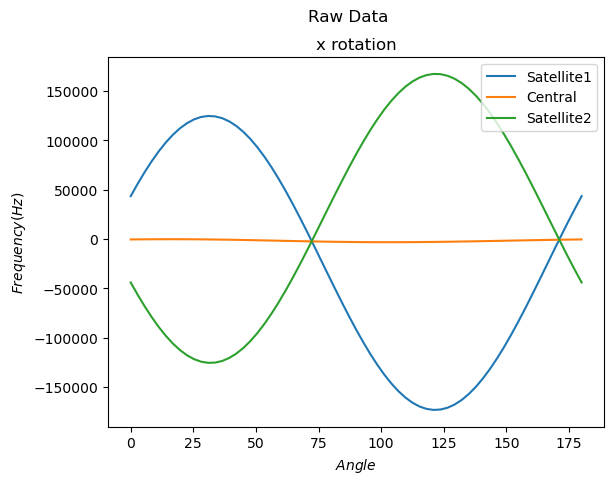

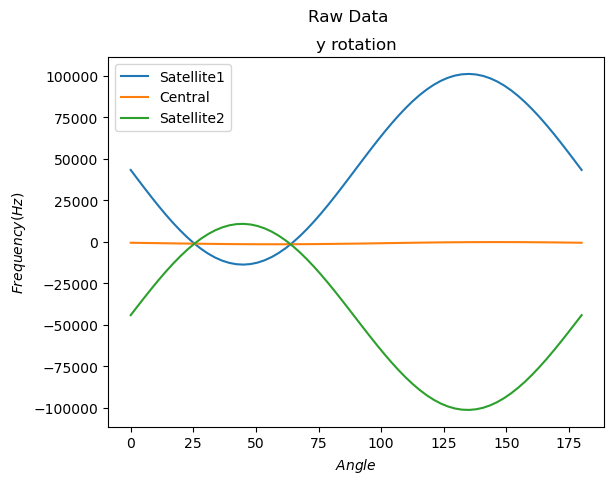

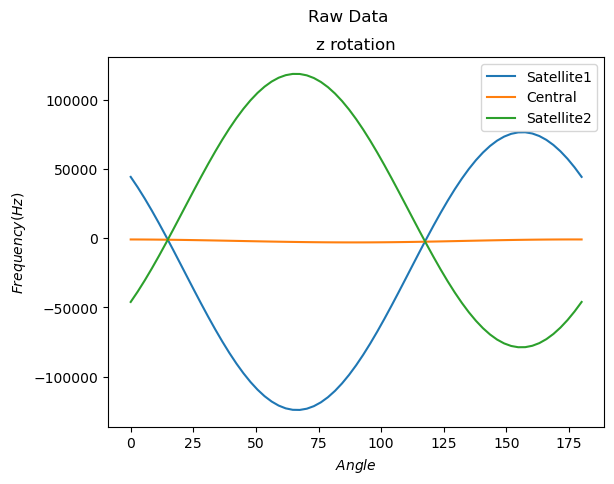

In [3]:
for i in range (3):
    plt.plot(df[i].angle, df[i].freq_3212, label = 'Satellite1')
    plt.plot(df[i].angle, df[i].freq_1212, label = 'Central')
    plt.plot(df[i].angle, df[i].freq_1232, label = 'Satellite2')
    plt.suptitle('Raw Data')
    plt.title(titles[i])
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    plt.legend()
    plt.show()

**Find H_Q(2) Tensor Components**

In [4]:
df_Q = [0]*3
for i in range(len(titles)):
    df_Q[i] =  -2*df[i].freq_1212 + df[i].freq_1232 + df[i].freq_3212 #from equation in Rotating Frame hamiltonian_32_52 word document
            

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.865e-18 (chi2/ndof = 0.0)│              Nfcn = 179              │
│ EDM = 1.61e-23 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

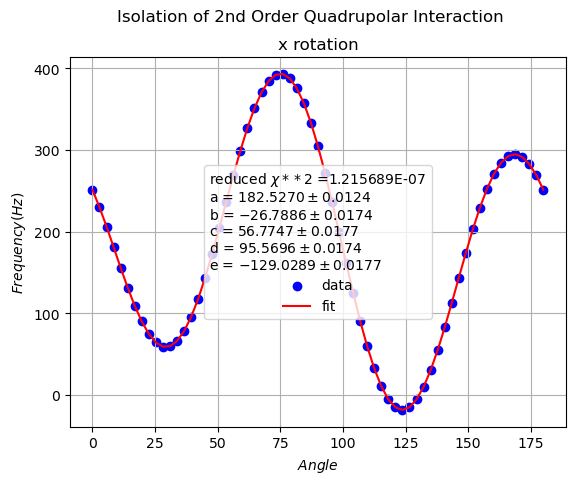

a = 182.52700789606118
b = -26.78864850065325
c = 56.77472383914473
d = 95.56962074170481
e = -129.02894082450496
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.976e-19 (chi2/ndof = 0.0)│              Nfcn = 177              │
│ EDM = 3.06e-24 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴──

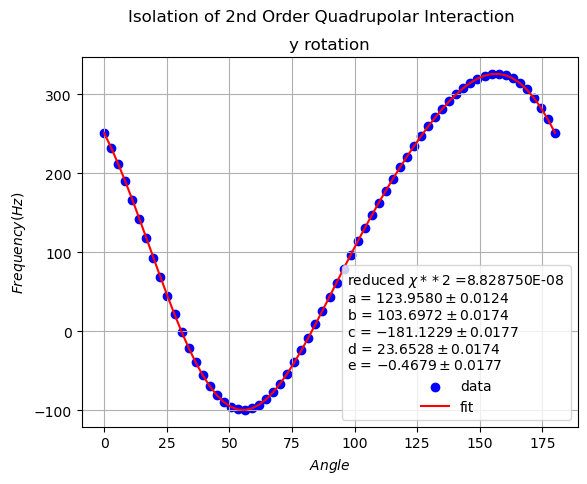

a = 123.95799773556071
b = 103.69719381160411
c = -181.12295110979196
d = 23.652788589951314
e = -0.46791402824700656
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.624e-19 (chi2/ndof = 0.0)│              Nfcn = 179              │
│ EDM = 3.84e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴──────────

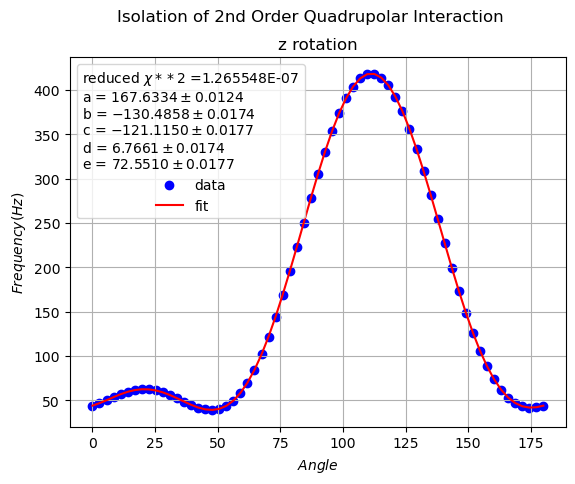

a = 167.6333488889821
b = -130.48584231225453
c = -121.1149545393386
d = 6.76608593718317
e = 72.55098490044558


In [5]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df_Q[i], 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df_Q[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier5(df[i].angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.suptitle('Isolation of 2nd Order Quadrupolar Interaction')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [6]:
a_Q = [0]*3; 
b_Q = [0]*3; 
c_Q = [0]*3; 
d_Q = [0]*3
e_Q = [0]*3

par_Q = [a_Q, b_Q, c_Q, d_Q, e_Q]
for i in range(0,3):
    for k in range(len(par_Q)):
        par_Q[k][i] = m_Q[i].values[k]

Dx = d_Q[0]*wX*72;
Ex = e_Q[0]*wX*72;

Dy = d_Q[1]*wX*72;
Ey = e_Q[1]*wX*72;

Dz = d_Q[2]*wX*72;
Ez = e_Q[2]*wX*72;

#solving equations for Isolation of 2nd order Uadrupolar Interaction
gyz2 = (Dx + np.sqrt(Dx**2+Ex**2))/(2*102/4);
gyz_q = -np.sqrt(gyz2); 
gzzmgyy = (4*Ex/102)*(1/gyz_q);

# print(Dx)

gxz2 = (Dy + np.sqrt(Dy**2+Ey**2))/(2*102/4);
gxz_q = np.sqrt(gxz2);
gzzmgxx = -(4*Ey/102)*(1/gxz_q);

# print(Gxz_Q)

gxy2 = (Dz + np.sqrt(Dz**2+Ez**2))/(2*102/4);
gxy_q = np.sqrt(gxy2);
gxxmgyy = (4*Ez/102)*(1/gxy_q);

# print(Gxy_Q)

gzz1 = (gzzmgyy + gzzmgxx)/3
gyy1 = gzz1 -gzzmgyy
gxx1 = gzz1 -gzzmgxx

gxx2 = (gxxmgyy-gzzmgxx)/3
gzz2 = gxx2+gzzmgxx
gyy2 = gxx2-gxxmgyy

gyy3 = -(gzzmgyy + gxxmgyy)/3
gzz3 = gyy3 + gzzmgyy
gxx3 = gyy3 + gxxmgyy

gxx_q = (gxx1+gxx2+gxx3)/3;
gyy_q = (gyy1+gyy2+gyy3)/3;
gzz_q = (gzz1+gzz2+gzz3)/3;

# print(Gxx, Gyy, Gzz)

QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

QXG_f = -QXG_f;


# print(Gzz1, Gzz2, Gzz3)
print('Input Quadrupolar Tensor:\n', QXG)
print('Calculated Quad Tensor:\n',QXG_f)

Input Quadrupolar Tensor:
 [[  90099.80538242  147109.26901107 -113389.78767716]
 [ 147109.26901107 -177956.68358649 -263835.38836225]
 [-113389.78767716 -263835.38836225   87856.87820407]]
Calculated Quad Tensor:
 [[ -88604.52059685 -147109.26901107 -113389.78767717]
 [-147109.26901107  177956.68358649  263835.38836225]
 [-113389.78767717  263835.38836225  -89352.16298964]]


**Find HQ1 and HQ2 Tensor Components**

In [7]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2  

**Find HCSA1**

┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216  2.64e-10 │
│ b │   -0.0216         1 -3.83e-09 │
│ c │  2.64e-10 -3.83e-09         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.9024 (chi2/ndof = 0.0)   │              Nfcn = 95               │
│ EDM = 5.04e-22 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬──

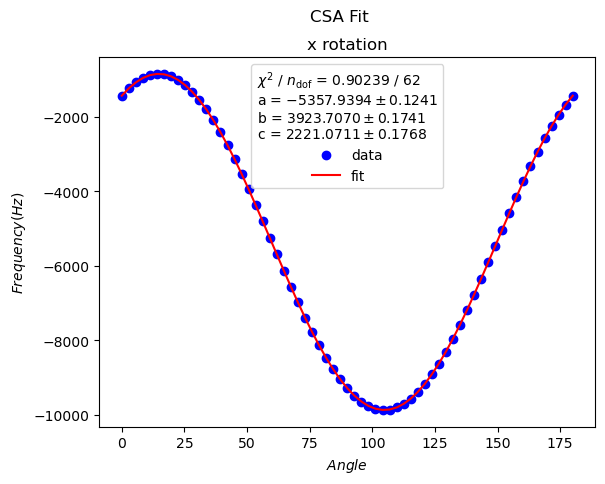

a = -5357.939455586211
b = 3923.706988188581
c = 2221.0711190562915
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216  1.99e-09 │
│ b │   -0.0216         1 -1.95e-09 │
│ c │  1.99e-09 -1.95e-09         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.132 (chi2/ndof = 0.0)    │              Nfcn = 97               │
│ EDM = 1.67e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call 

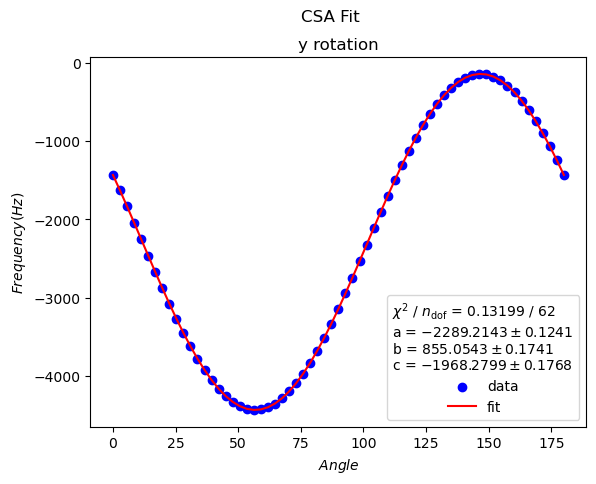

a = -2289.2143061428796
b = 855.054352682769
c = -1968.2799268060364
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216  3.54e-10 │
│ b │   -0.0216         1 -1.38e-08 │
│ c │  3.54e-10 -1.38e-08         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 0.411 (chi2/ndof = 0.0)    │              Nfcn = 95               │
│ EDM = 4.15e-21 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call

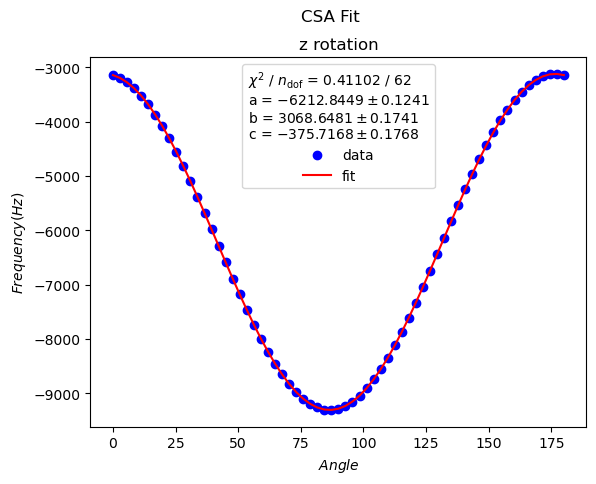

a = -6212.844886625225
b = 3068.6481097050428
c = -375.7168058092908


In [8]:
HQ2_freq_sum = [0]*3
csa = [0]*3
m_csa = [0]*3

for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    csa[i] = df[i].freq_sum - HQ2_freq_sum[i]  
    least_squares = LeastSquares(df[i].angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
    # m[i] = m[i].scan(ncall = 50)

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m_csa[i].fval:.5f} / {len(df[i].angle) - m_csa[i].nfit}",
    ]
    # print(fit_info)
    

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_csa[i].values), label="fit", color = 'red')
    
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Titles
    plt.suptitle('CSA Fit')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [9]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;


print('Input CSA Tensor:\n', CsaQXG)
print('Calculated CSA Tensor:\n',CsaQXG_f)


print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

Input CSA Tensor:
 [[-1048.06093827   116.62890646  -660.46094326]
 [  116.62890646 -3093.85677048  -735.50029231]
 [ -660.46094326  -735.50029231  -478.08229124]]
Calculated CSA Tensor:
 [[-1048.07757262   125.23893527  -656.09330894]
 [  125.23893527 -3093.85657335  -740.35703969]
 [ -656.09330894  -740.35703969  -478.06540348]]
-------  -----------
gxx_q      88604.5
gyy_q    -177957
gzz_q      89352.2
gxy_q     147109
gyz_q    -263835
gxz_q     113390
gxx_csa    -1048.08
gyy_csa    -3093.86
gzz_csa     -478.065
gxy_csa      125.239
gyz_csa     -740.357
gxz_csa     -656.093
-------  -----------


In [10]:
eigenvalues, eigenvectors = np.linalg.eig(QXG_f)
D_quad = np.diag(eigenvalues)
print('Diagonalized Quadrupolar Tensor:\n', D_quad)
sorted_eigenvalues = sorted(eigenvalues, key=abs)


print('Sorted Eigenvalues of Quadrupolar diagonal matrix:\n', sorted_eigenvalues) #See Haberlen convention for details [ref: Single-Crystal NMR Spectroscopy – Method Development and Application to Inorganic Solids]

Gzz_q = sorted_eigenvalues[2]
Gyy_q = sorted_eigenvalues[1]
Gxx_q = sorted_eigenvalues[0]

print('Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): \n', Gzz_q, Gyy_q, Gxx_q)

print('================================================================================================')

eigenvalues, eigenvectors = np.linalg.eig(CsaQXG_f)
D_csa = np.diag(eigenvalues)

print('Diagonalized CSA Tensor:\n',D_csa)
csa_avg = np.mean(eigenvalues)

sorted_eigenvalues = sorted((eigenvalues - csa_avg), key = abs) #See Haberlen convention for details

print('Sorted Eigenvalues (Eigenvalue - isotropic CS)  of CSA diagonal matrix:\n',sorted_eigenvalues )

Gzz_csa = sorted_eigenvalues[2] + csa_avg
Gxx_csa = sorted_eigenvalues[1] + csa_avg 
Gyy_csa = sorted_eigenvalues[0] + csa_avg

print('CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : \n', Gzz_csa, Gyy_csa, Gxx_csa)

Diagonalized Quadrupolar Tensor:
 [[ 408733.86886962       0.               0.        ]
 [      0.         -153755.304082         0.        ]
 [      0.               0.         -254978.56478762]]
Sorted Eigenvalues of Quadrupolar diagonal matrix:
 [-153755.30408200395, -254978.5647876206, 408733.86886962457]
Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): 
 408733.86886962457 -254978.5647876206 -153755.30408200395
Diagonalized CSA Tensor:
 [[  102.92561374     0.             0.        ]
 [    0.         -1433.04984242     0.        ]
 [    0.             0.         -3289.87532076]]
Sorted Eigenvalues (Eigenvalue - isotropic CS)  of CSA diagonal matrix:
 [106.95000739287866, 1642.9254635533698, -1749.8754709462485]
CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : 
 -3289.875320763395 -1433.0498424242678 102.92561373622334


**Fit Values**

In [11]:
#****** Input Vaue****************



#for CSA
Siso_fit = (Gxx_csa + Gyy_csa + Gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = Gzz_csa/w0 - Siso_ppm_fit
eta_fit = (Gyy_csa - Gxx_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = Gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (Gxx_q - Gyy_q)/Gzz_q

table = [['Siso',Siso_ppm_fit, Siso_ppm, abs(Siso_ppm_fit - Siso_ppm)*100/Siso_ppm, ],['delta', delta_fit, delta_ppm, abs(delta_fit - delta_ppm)*100/delta_ppm],  ['eta', eta_fit, eta, abs(eta_fit - eta)*100/eta],  ['CQ', CQ_fit, CQ_M, abs((CQ_fit - CQ_M)/CQ_M)*100], ['Qeta', Qeta_fit ,Qeta, abs(Qeta_fit - Qeta)*100/Qeta]]
print(tabulate(table, headers=['Qauntity', 'Fit Value','Input Value', '% difference']))

Qauntity      Fit Value    Input Value    % difference
----------  -----------  -------------  --------------
Siso          -8                -8        -9.75213e-06
delta         -9.09026          -9.08     -0.11302
eta            0.877763          0.88      0.254236
CQ             2.4524            2.18     12.4956
Qeta           0.247651          0.935    73.5133


**Find HCSA1 and HQ,CSA**

In [12]:
HCSA1_freq_3212 = [0]*3
HCSA1_freq_1212 = [0]*3
HCSA1_freq_1232 = [0]*3


HQCSA_freq_3212 = [0]*3
HQCSA_freq_1212 = [0]*3
HQCSA_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)
    R2m1cs, R20cs, R2p1cs = ChemShift(CsaQXG_f,ct, st, s2t, c2t, cp, sp, c2p, s2p)
    

            
    HCSA1 = (R20cs + 1/3*(CsaQXG_f[2, 2] + CsaQXG_f[0,0] + CsaQXG_f[1,1]))                       # Siso = 1/3*(CsaQXG[2, 2] + CsaQXG[0,0] + CsaQXG[1,1]); Siso added to CSA tensor
    HQCSA = -(0.5/(2*Ispin*(2*Ispin-1)))*(R2m1Q*R2p1cs+R2p1Q*R2m1cs)/wX;


    HCSA1_freq_3212[i] = 1*np.real(HCSA1)               # 3/2 <-> 1/2
    HCSA1_freq_1212[i] = 1*np.real(HCSA1)               # 1/2 <-> -1/2
    HCSA1_freq_1232[i] = 1*np.real(HCSA1)             #-1/2   <-> -3/2       
    
    HQCSA_freq_3212[i] = 6*(np.real(HQCSA))       # 3/2 <-> 1/2
    HQCSA_freq_1212[i] = 0*(np.real(HQCSA))       # 1/2 <-> -1/2
    HQCSA_freq_1232[i] = -6*(np.real(HQCSA))      #-1/2   <-> -3/2   

**Fit HQ_ACS**

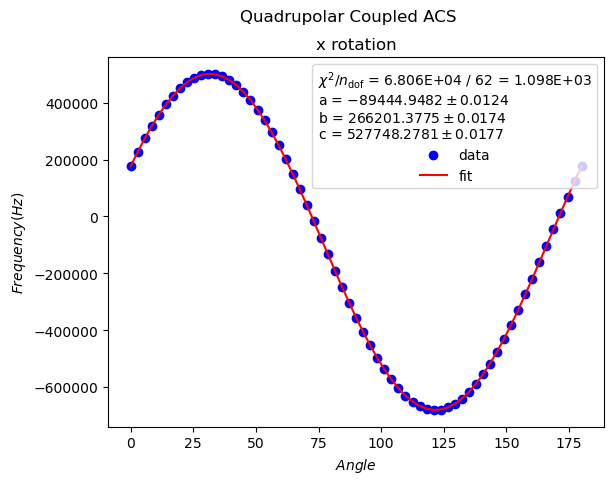

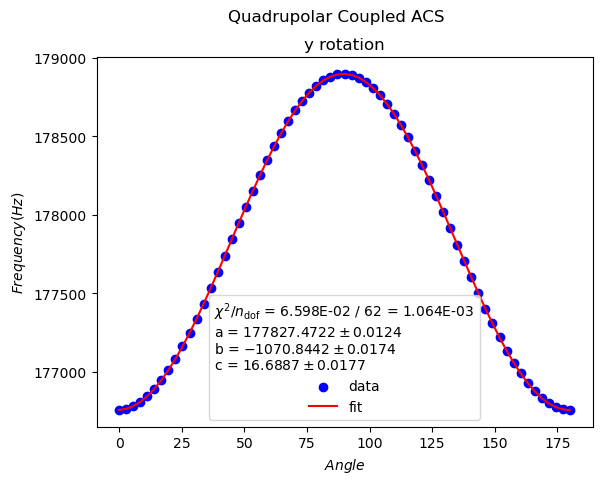

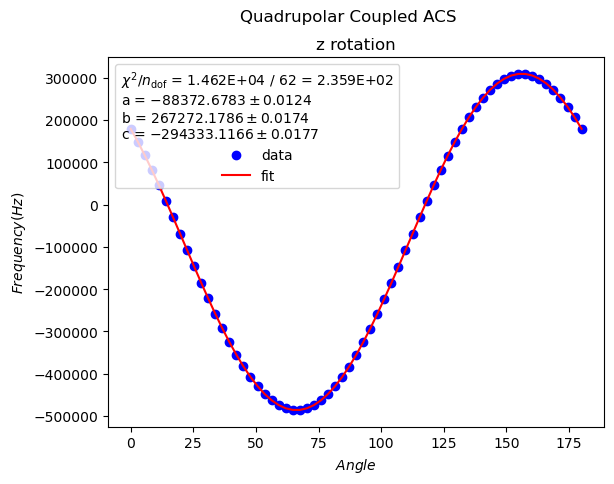

In [13]:
HACS_freq_3212 = [0]*3
HACS_freq_1212 = [0]*3
HACS_freq_1232 = [0]*3

acs = [0]*3
m_acs = [0]*3

for i in range (3):
    HACS_freq_3212[i] = df[i].freq_3212 - (HQ1_freq_3212[i] + HQ2_freq_3212[i] + HCSA1_freq_3212[i] + HQCSA_freq_3212[i])
    HACS_freq_1212[i] = df[i].freq_1212 - (HQ1_freq_1212[i] + HQ2_freq_1212[i] + HCSA1_freq_1212[i] + HQCSA_freq_1212[i])
    HACS_freq_1232[i] = df[i].freq_1232 - (HQ1_freq_1232[i] + HQ2_freq_1232[i] + HCSA1_freq_1232[i] + HQCSA_freq_1232[i])

    acs[i] = HACS_freq_3212[i] - HACS_freq_1232[i] 

    least_squares = LeastSquares(df[i].angle, acs[i], 0.1,fourier3)

    #***********************Trying to fit input ACS ****************
    # least_squares = LeastSquares(df[i].angle, df[i].acs, 0.1,fourier3)

    m_acs[i] = Minuit(least_squares, a = 1000, b = 100, c= 100)
    # m_acs[i].fixed["c"] = True
    # # m_d[i].fixed["b"] = True
    # # m[i] = m[i].scan(ncall = 50)

    m_acs[i].migrad()  # finds minimum of least_squares function
    m_acs[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_acs[i].fval:.3E} / {m_acs[i].ndof:.0f} = {m_acs[i].fmin.reduced_chi2:.3E}",
    ]
    
    

    for p, v, e in zip(m_acs[i].parameters, m_acs[i].values, m_acs[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    # corr_mat = (m_acs[i].covariance.correlation())
    # # print(corr_mat)
    # # print(m_d[i].migrad())
    # # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, acs[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_acs[i].values), label="fit", color = 'red')

    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Titles
    plt.suptitle('Quadrupolar Coupled ACS')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()

In [14]:
a_acs = [0]*3; 
b_acs = [0]*3; 
c_acs = [0]*3; 

par_acs = [a_acs, b_acs, c_acs]

for i in range(0,3):
    for k in range(len(par_acs)):
        par_acs[k][i] = m_acs[i].values[k]

In [15]:
#-X rotation
gxy_acs1, gxz_acs1, gyz_acs1 = sym.symbols('gxy_acs1, gxz_acs1, gyz_acs1')

# To see how to solve simultaneous equations https://reliability.readthedocs.io/en/latest/Solving%20simultaneous%20equations%20with%20sympy.html

eq1 = sym.Eq(-(gxy_q*gxy_acs1 + gxz_q*gxz_acs1)/-wX, a_acs[0])
eq2 = sym.Eq((gxy_q*gxy_acs1 - gxz_q*gxz_acs1 - 2*gyz_q*gyz_acs1)/-wX, b_acs[0])
eq3 = sym.Eq((gxz_q*gxy_acs1 + gxy_q*gxz_acs1 - (gzz_q - gyy_q)*gyz_acs1)/-wX, c_acs[0])
result1 = sym.solve([eq1, eq2, eq3], (gxy_acs1, gxz_acs1, gyz_acs1))

print(result1)

{gxy_acs1: -1591719637.03323, gxz_acs1: 1913210741.38693, gyz_acs1: 757767010.205233}


In [16]:
#Y rotation
gxy_acs2, gxz_acs2, gyz_acs2 = sym.symbols('gxy_acs2, gxz_acs2, gyz_acs2')


eq1 = sym.Eq((gxy_q*gxy_acs2 - gyz_q*gyz_acs2)/-wX, a_acs[1])
eq2 = sym.Eq(-(gxy_q*gxy_acs2 +  gyz_q*gyz_acs2 +2*gxz_q*gxz_acs2 )/-wX , b_acs[1])
eq3 = sym.Eq((gyz_q*gxy_acs2 - gxy_q*gyz_acs2 + (gzz_q - gxx_q)*gxz_acs2   )/-wX, c_acs[1])
result2 = sym.solve([eq1, eq2, eq3], (gxy_acs2, gxz_acs2, gyz_acs2))

print(result2)

{gxy_acs2: 103822125.316045, gxz_acs2: -286552789.049432, gyz_acs2: -187635880.319707}


In [17]:
#-Z rotation
gxy_acs3, gxz_acs3, gyz_acs3 = sym.symbols('gxy_acs3, gxz_acs3, gyz_acs3')


eq1 = sym.Eq((gxz_q*gxz_acs3 + gyz_q*gyz_acs3)/-wX, a_acs[2])
eq2 = sym.Eq((gxz_q*gxz_acs3 - gyz_q*gyz_acs3 + 2*gxy_q*gxy_acs3)/-wX , b_acs[2])
eq3 = sym.Eq(-((gyy_q - gxx_q)*gxy_acs3 + gxz_q*gyz_acs3 + gyz_q*gxz_acs3)/-wX, c_acs[2])
result3 = sym.solve([eq1, eq2, eq3], (gxy_acs3, gxz_acs3, gyz_acs3))

print(result3)

{gxy_acs3: -6556401768.55401, gxz_acs3: 8354265529.69106, gyz_acs3: 3525973751.35078}


In [18]:
# dictionryList = [result1, result2, result3]
# new = {}
gxy_acs = np.mean([result1[gxy_acs1], result2[gxy_acs2], result3[gxy_acs3]])
gxz_acs = np.mean([result1[gxz_acs1], result2[gxz_acs2], result3[gxz_acs3]])
gyz_acs = np.mean([result1[gyz_acs1], result2[gyz_acs2], result3[gyz_acs3]])

# print(gxy_acs, gxz_acs, gyz_acs)

AcsQXG_f = np.zeros((3, 3))                                #Tensor from fitting
AcsQXG_f[0,1]=gxy_acs; AcsQXG_f[0,2]=gxz_acs;
AcsQXG_f[1,0]=-gxy_acs;  AcsQXG_f[1,2]=gyz_acs;
AcsQXG_f[2,0]=-gxz_acs; AcsQXG_f[2,1]=-gyz_acs; 

AcsQXG_f = -AcsQXG_f
print('Input ACS Tensor:\n', AcsQXG)
print('Calculated ACS Tensor:\n',AcsQXG_f)

Input ACS Tensor:
 [[ 2.93742061e-11 -5.94468865e+04  8.72271314e+04]
 [ 5.94468865e+04 -1.79938029e-11  1.29033650e+05]
 [-8.72271314e+04 -1.29033650e+05 -1.32817650e-11]]
Calculated ACS Tensor:
 [[-0.00000000e+00  2.68143309e+09 -3.32697449e+09]
 [-2.68143309e+09 -0.00000000e+00 -1.36536829e+09]
 [ 3.32697449e+09  1.36536829e+09 -0.00000000e+00]]
